In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from mypackages import file_io, front_analysis, p_inj_analysis, plotting

my package loaded


In [2]:
result_dir = Path.cwd().parent / "results" / "3dec"
run_stress_bc = file_io.read_run(result_dir / "stress-bc" / "q-5e-07-fine.hdf5")
run_disp_bc = file_io.read_run(result_dir / "wi-1e-05" / "q-5e-07.hdf5")

result_halfspace_dir = Path.cwd().parent / "results" / "fvm-elastic"
run_halfspace = file_io.read_fvm(result_halfspace_dir / "stress-bc" / "q-5e-07.hdf5")

figures_dir = Path.cwd().parent / "figures" / "bc-effect"

## Compare stress, pressure and aperture profiles.

In [3]:
def shared_t_values(*runs, n=6, t_start=None):
    """Evenly spaced times within the overlap of several runs' time ranges."""
    t_min = t_start if t_start is not None else max(r.t[0] for r in runs)
    t_max = min(r.t[-1] for r in runs)
    return np.linspace(t_min, t_max, n)


def plot_profiles(ax, x, t, field, N=None, t_values=None, **kwargs):
    """Plot profiles colored by viridis, with a legend.

    Either pass N (evenly-spaced-in-time, based on this dataset's own t),
    or pass explicit t_values (e.g. shared across multiple datasets) —
    in which case the nearest available index in `t` is used for each.
    """
    t = np.asarray(t)
    if t_values is None:
        assert N is not None
        indices = range(len(t) // 100, len(t), len(t) // N)
        t_values = [t[i] for i in indices]
    else:
        indices = [np.argmin(np.abs(t - tv)) for tv in t_values]

    colors = plt.cm.viridis(  # pyright: ignore[reportAttributeAccessIssue]
        np.linspace(0, 1, len(indices))
    )
    for c, i in zip(colors, indices):
        ax.plot(x, field[i], color=c, label=rf"$t={t[i]:.0f}\,\mathrm{{s}}$", **kwargs)
    ax.ticklabel_format(useMathText=True)
    ax.set_xlabel("Distance [m]")


def add_style_legend(ax, style_labels, time_legend_kwargs=None, loc="center right"):
    """Add a linestyle→model legend alongside the existing time→color legend.

    style_labels: dict mapping linestyle (e.g. "-") to its label (e.g. "3DEC").
    """
    time_legend = ax.legend(**(time_legend_kwargs or dict(ncols=2)))
    ax.add_artist(time_legend)
    handles = [
        Line2D([0], [0], color="k", ls=ls, label=lbl)
        for ls, lbl in style_labels.items()
    ]
    ax.legend(handles=handles, loc=loc)


def savefig(fig, name, **kwargs):
    fig.savefig(figures_dir / name, **kwargs)

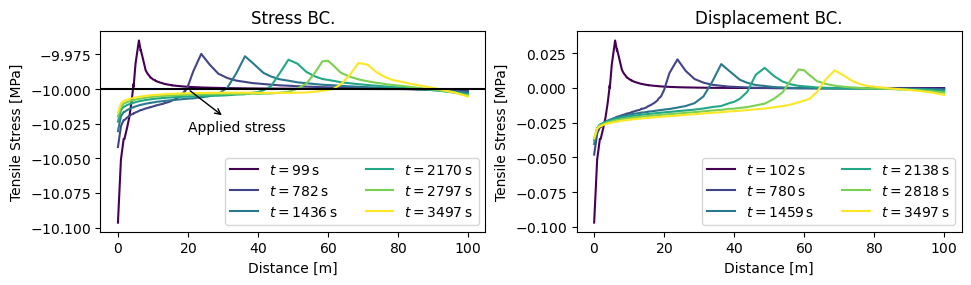

In [4]:
fig = plt.figure(
    figsize=(6.4 * 1.5, 4.8 / 1.75), dpi=100, layout="constrained", clear=True, num=1
)
ax1, ax2 = fig.subplots(1, 2)
t_values = shared_t_values(run_stress_bc, run_disp_bc, t_start=100)

plot_profiles(
    ax1, run_stress_bc.x_sc, run_stress_bc.t, -run_stress_bc.sn / 1e6, t_values=t_values
)
ax1.axhline(-10e6 / 1e6, color="k")
ax1.annotate(
    "Applied stress",
    xy=(20, -10),
    xytext=(0, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-", shrinkA=2, shrinkB=2),
)
ax1.set(ylabel="Tensile Stress [MPa]", title="Stress BC.")
ax1.legend(ncols=2)

plot_profiles(
    ax2, run_disp_bc.x_sc, run_disp_bc.t, -run_disp_bc.sn / 1e6, t_values=t_values
)
ax2.set(ylabel="Tensile Stress [MPa]", title="Displacement BC.")
ax2.legend(ncols=2)

# savefig(fig, "stress-profiles.png")
fig.canvas.draw_idle()
plt.pause(0.01)

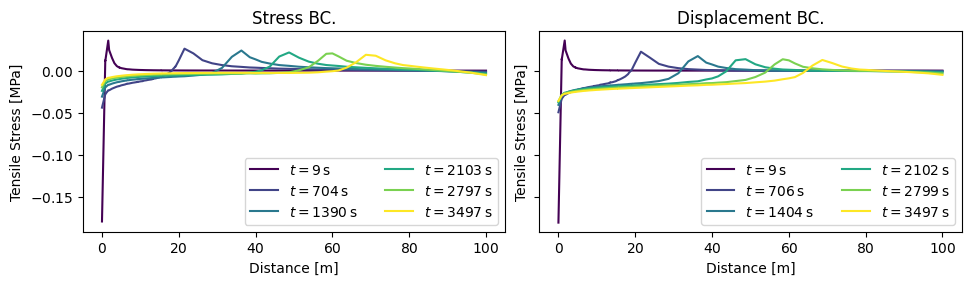

In [5]:
fig = plt.figure(
    figsize=(6.4 * 1.5, 4.8 / 1.75), dpi=100, layout="constrained", clear=True, num=1
)
ax1, ax2 = fig.subplots(1, 2, sharey=True)
t_values = shared_t_values(run_stress_bc, run_disp_bc)

plot_profiles(
    ax1,
    run_stress_bc.x_sc,
    run_stress_bc.t,
    -run_stress_bc.sn / 1e6 + 10,
    t_values=t_values,
)
ax1.annotate(
    "Applied stress",
    xy=(20, -10),
    xytext=(0, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-", shrinkA=2, shrinkB=2),
)
ax1.set(ylabel="Tensile Stress [MPa]", title="Stress BC.")
ax1.legend(ncols=2)

plot_profiles(
    ax2, run_disp_bc.x_sc, run_disp_bc.t, -run_disp_bc.sn / 1e6, t_values=t_values
)
ax2.set(ylabel="Tensile Stress [MPa]", title="Displacement BC.")
ax2.legend(ncols=2)

# savefig(fig, "stress-profiles-sharedy.png")
fig.canvas.draw_idle()
plt.pause(0.01)

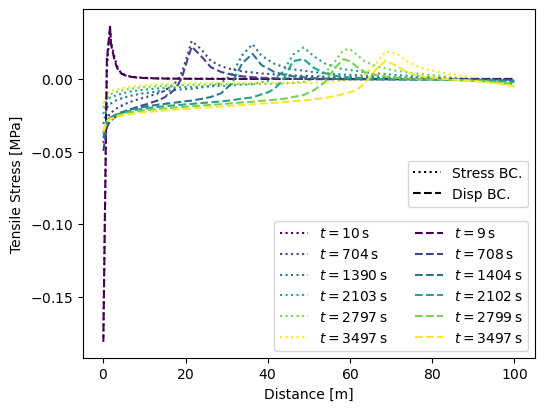

In [15]:
fig = plt.figure(
    figsize=(6.4 / 1.2, 4.8 / 1.2), dpi=100, layout="constrained", clear=True, num=1
)
ax = fig.subplots()
t_values = shared_t_values(run_stress_bc, run_disp_bc, t_start=10)

plot_profiles(
    ax,
    run_stress_bc.x_sc,
    run_stress_bc.t,
    -run_stress_bc.sn / 1e6 + 10,
    t_values=t_values,
    ls=":",
)
plot_profiles(
    ax,
    run_disp_bc.x_sc,
    run_disp_bc.t,
    -run_disp_bc.sn / 1e6,
    t_values=t_values,
    ls="--",
)
ax.set(ylabel="Tensile Stress [MPa]")
add_style_legend(ax, {":": "Stress BC.", "--": "Disp BC."})

# savefig(fig, "stress-vs-disp.png")
fig.canvas.draw_idle()
plt.pause(0.01)

## Investigating mesh size effect via comparison with half space code

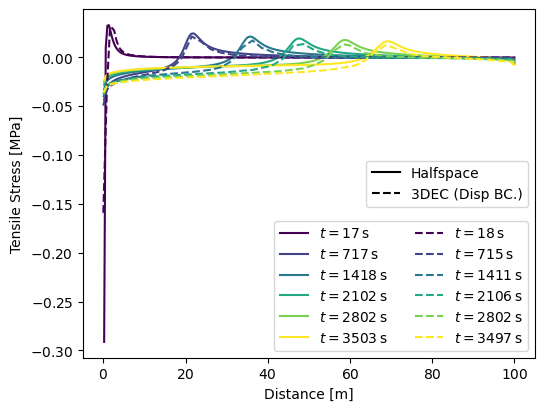

In [7]:
fig = plt.figure(
    figsize=(6.4 / 1.2, 4.8 / 1.2), dpi=100, layout="constrained", clear=True, num=1
)
ax = fig.subplots()
t_values = shared_t_values(run_stress_bc, run_disp_bc, t_start=20)

plot_profiles(
    ax,
    run_halfspace.x_sc,
    run_halfspace.t,
    -run_halfspace.sn / 1e6,
    t_values=t_values,
    ls="-",
)
plot_profiles(
    ax,
    run_disp_bc.x_sc,
    run_disp_bc.t,
    -run_disp_bc.sn / 1e6,
    t_values=t_values,
    ls="--",
)
ax.set(ylabel="Tensile Stress [MPa]")
add_style_legend(ax, {"-": "Halfspace", "--": "3DEC (Disp BC.)"})

# savefig(fig, "halfspace-vs-disp.png")
fig.canvas.draw_idle()
plt.pause(0.01)

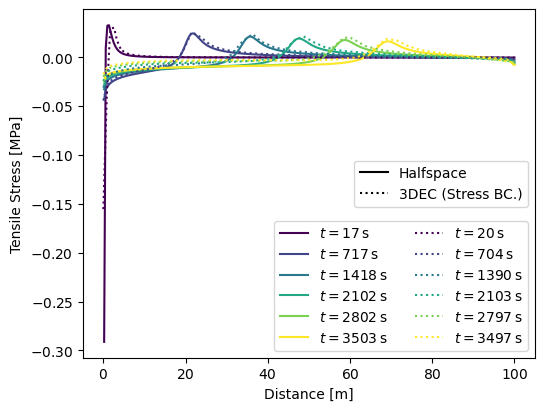

In [8]:
fig = plt.figure(
    figsize=(6.4 / 1.2, 4.8 / 1.2), dpi=100, layout="constrained", clear=True, num=1
)
ax = fig.subplots()
t_values = shared_t_values(run_stress_bc, run_disp_bc, t_start=20)

plot_profiles(
    ax,
    run_halfspace.x_sc,
    run_halfspace.t,
    -run_halfspace.sn / 1e6,
    t_values=t_values,
    ls="-",
)
plot_profiles(
    ax,
    run_stress_bc.x_sc,
    run_stress_bc.t,
    -run_stress_bc.sn / 1e6 + 10,
    t_values=t_values,
    ls=":",
)
ax.set(ylabel="Tensile Stress [MPa]")
add_style_legend(ax, {"-": "Halfspace", ":": "3DEC (Stress BC.)"})

# savefig(fig, "halfspace-vs-stress.png")
fig.canvas.draw_idle()
plt.pause(0.01)

Aperture and pressure profiles

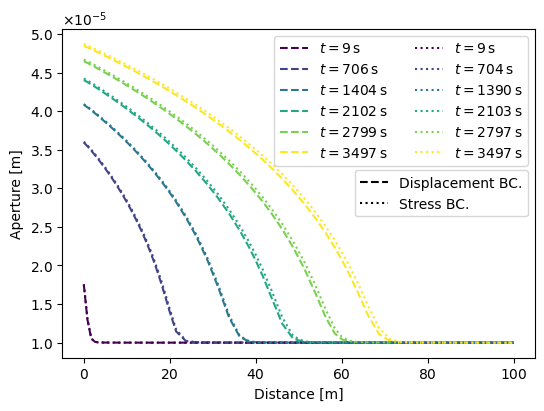

In [16]:
fig = plt.figure(
    figsize=(6.4 / 1.2, 4.8 / 1.2), dpi=100, layout="constrained", clear=True, num=1
)
ax = fig.subplots()
t_values = shared_t_values(run_stress_bc, run_disp_bc)

plot_profiles(
    ax, run_disp_bc.x_vert, run_disp_bc.t, run_disp_bc.w, t_values=t_values, ls="--"
)
plot_profiles(
    ax,
    run_stress_bc.x_vert,
    run_stress_bc.t,
    run_stress_bc.w,
    t_values=t_values,
    ls=":",
)
ax.set(ylabel="Aperture [m]")
add_style_legend(ax, {"--": "Displacement BC.", ":": "Stress BC."})

# savefig(fig, "aperture_profiles.png")
fig.canvas.draw_idle()
plt.pause(0.01)

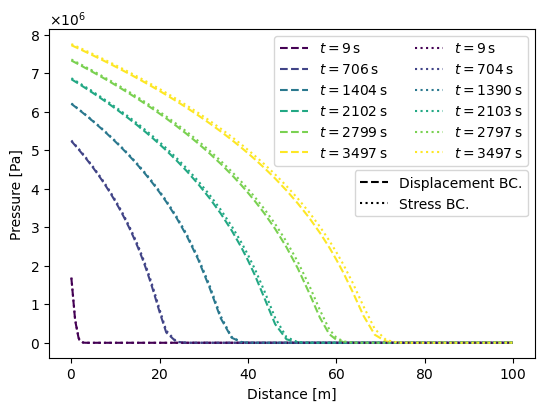

In [10]:
fig = plt.figure(
    figsize=(6.4 / 1.2, 4.8 / 1.2), dpi=100, layout="constrained", clear=True, num=1
)
ax = fig.subplots()
t_values = shared_t_values(run_stress_bc, run_disp_bc)

plot_profiles(
    ax, run_disp_bc.x_sc, run_disp_bc.t, run_disp_bc.p, t_values=t_values, ls="--"
)
plot_profiles(
    ax, run_stress_bc.x_sc, run_stress_bc.t, run_stress_bc.p, t_values=t_values, ls=":"
)
ax.set(ylabel="Pressure [Pa]")
add_style_legend(ax, {"--": "Displacement BC.", ":": "Stress BC."})

# savefig(fig, "pressure_profiles.png", dpi=200)
fig.canvas.draw_idle()
plt.pause(0.01)

## Front Migration

In [25]:
result_stress_bc = front_analysis.analyze(run_stress_bc, stress_front=True)
result_disp_bc = front_analysis.analyze(run_disp_bc, stress_front=True)

idx_crossover = 180
result_stress_bc_early = front_analysis.analyze_rigid(
    run_stress_bc, stress_front=True, slc=slice(50, idx_crossover)
)
result_stress_bc_late = front_analysis.analyze_soft(
    run_stress_bc, stress_front=True, slc=slice(idx_crossover, None)
)

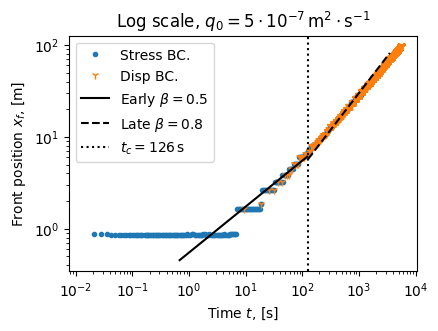

In [26]:
fig = plt.figure(
    figsize=(6.4 / 1.5, 4.8 / 1.5), dpi=100, layout="constrained", clear=True, num=1
)
ax = fig.subplots()

ax.plot(
    result_stress_bc.t_front,
    result_stress_bc.x_front,
    ".",
    color="tab:blue",
    label="Stress BC.",
)
ax.plot(
    result_disp_bc.t_front,
    result_disp_bc.x_front,
    "1",
    color="tab:orange",
    label="Disp BC.",
)
ax.plot(
    result_stress_bc_early.t_front,
    result_stress_bc_early.x_analytical(),
    "-",
    color="k",
    label=rf"Early $\beta={result_stress_bc_early.alpha_ana}$",
)
ax.plot(
    result_stress_bc_late.t_front,
    result_stress_bc_late.x_analytical(),
    "--",
    color="k",
    label=rf"Late $\beta={result_stress_bc_late.alpha_ana}$",
)
ax.axvline(
    run_stress_bc.t[idx_crossover],
    color="k",
    ls=":",
    label=rf"$t_c={run_stress_bc.t[idx_crossover]:.0f}\,\mathrm{{s}}$",
)
log_scale = True
q_0_title = rf"$q_0={plotting.sci_latex(run_stress_bc.params.q_0)}\,\mathrm{{ m^2 \cdot s^{{-1}} }}$"
title = rf"Log scale, {q_0_title}" if log_scale else rf"Linear scale, {q_0_title}"
ax.set(
    xlabel="Time $t$, [s]",
    ylabel="Front position $x_f$, [m]",
    xscale="log" if log_scale else "linear",
    yscale="log" if log_scale else "linear",
    title=title,
)

ax.legend()
# savefig(fig, 'front-migration.png', dpi=200)
plt.pause(0.01)

## Pressure (or aperture) at the injection point

In [13]:
result_pinj_stress_bc = p_inj_analysis.analyze(run_stress_bc)
result_pinj_stress_bc_early = p_inj_analysis.analyze_rigid(run_stress_bc)
result_pinj_stress_bc_late = p_inj_analysis.analyze_soft(run_stress_bc)

result_pinj_disp_bc = p_inj_analysis.analyze(run_disp_bc)

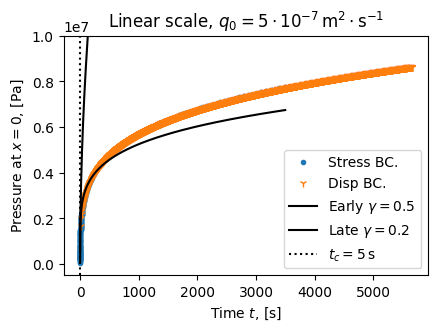

In [34]:
fig = plt.figure(
    figsize=(6.4 / 1.5, 4.8 / 1.5), dpi=100, layout="constrained", clear=True, num=1
)
ax = fig.subplots()

ax.plot(run_stress_bc.t, result_pinj_stress_bc.p_inj_num, ".", label="Stress BC.")
ax.plot(run_disp_bc.t, result_pinj_disp_bc.p_inj_num, "1", label="Disp BC.")
ax.plot(
    run_stress_bc.t,
    result_pinj_stress_bc_early.p_inj_fit_ana(run_stress_bc.t),
    "k-",
    label=rf"Early $\gamma={result_pinj_stress_bc_early.alpha_ana}$",
)
ax.plot(
    run_stress_bc.t,
    result_pinj_stress_bc_late.p_inj_fit_ana(run_stress_bc.t) / 1.4,
    "k-",
    label=rf"Late $\gamma={result_pinj_stress_bc_late.alpha_ana}$",
)
idx_crossover = 90
ax.axvline(
    run_stress_bc.t[idx_crossover],
    color="k",
    ls=":",
    label=rf"$t_c={run_stress_bc.t[idx_crossover]:.0f}\,\mathrm{{s}}$",
)

log_scale = True
q_0_title = rf"$q_0={plotting.sci_latex(run_stress_bc.params.q_0)}\,\mathrm{{ m^2 \cdot s^{{-1}} }}$"
title = rf"Log scale, {q_0_title}" if log_scale else rf"Linear scale, {q_0_title}"
ax.set(
    xlabel="Time $t$, [s]",
    ylabel="Pressure at $x=0$, [Pa]",
    xscale="log" if log_scale else "linear",
    yscale="log" if log_scale else "linear",
    title=title,
)
ax.legend()

# savefig(fig, 'pressure_at_injector.png', dpi=200)
plt.pause(0.01)